<a href="https://colab.research.google.com/github/zeinafarghaly-arch/ML-flyrank/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

This is a scoring task. The model gives each page a risk score for is_declining and ranks the pages from highest to lowest risk. This helps the reviewer check the most important pages first instead of checking every page.

The model does not make the final decision. A human still reviews the page and decides what to do. Choosing the wrong pages can waste the reviewer’s time (false positives) or miss pages that are actually declining (false negatives). Because of this, the most important metric is precision at the top of the ranked list, not overall accuracy.

In [1]:
import pandas as pd

from google.colab import files
uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded)))

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Clients: {df['client_id'].nunique()}")

Saving content_refresh_anonymized.csv to content_refresh_anonymized.csv
Rows: 30,000
Columns: 44
Clients: 32


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Source: content_refresh_anonymized.csv

This is an anonymized dataset from the FlyRank ML Internship. We use a 30,000-row sample, not the full dataset.

Data: Each row represents one content page. The data covers the previous 90 days.
Size: 30,000 pages from 32 clients. client_id is only used to group the data and is not used as a model feature.
Label: We use trend_direction to create is_declining.
down → is_declining = 1
Other values → is_declining = 0
Features we removed

Some columns were removed because they could give the model the answer directly or indirectly:

trend_direction and trend_pct → used to create the label, so using them would cause data leakage.
impressions_last_30d and impressions_prev_30d → used to calculate the trend, so they could also leak the answer.
content_id and client_id → IDs, not useful features. client_id is only used for grouped data splitting.
Client names, domains, URLs, page titles, and search queries → these are not included in the dataset.

In [2]:
df["is_declining"] = (df["trend_direction"] == "down").astype(int)

print("Trend label distribution:")
print(df["trend_direction"].value_counts())
print()
print(f"Base decline rate (whole dataset): {df['is_declining'].mean():.3f}")
print(f"Missing search_volume: {df['search_volume'].isna().sum():,} rows")
print(f"Missing word_count:    {df['word_count'].isna().sum():,} rows")

Trend label distribution:
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64

Base decline rate (whole dataset): 0.542
Missing search_volume: 2,468 rows
Missing word_count:    7,699 rows


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Baseline

The baseline is a simple rule:

`0.6 × staleness + 0.4 × search demand`

Both values are scaled between 0 and 1. No model is trained. This gives us a simple method to compare against.

### Model

We use **Logistic Regression** with 6 features:

* `days_since_last_update`
* `search_volume`
* `avg_position`
* `ctr`
* `engagement_rate`
* `content_age_days`

We use `class_weight="balanced"` and `random_state=42`.

Logistic Regression was chosen because the target is a simple **yes/no outcome**. It also gives probabilities that can be used to rank pages from highest to lowest risk.

### Validation

We split the data by `client_id` instead of randomly splitting individual rows.

We use **GroupShuffleSplit** with 25% for testing and `random_state=42`.

This means that clients in the test set are completely different from the clients in the training set. This gives us a more realistic test of how the model works on new clients.

A normal random row split could put the same clients in both training and testing, which could make the model look better than it really is.

### Leakage Check

We add the excluded features back **one at a time** and check how much **Precision@500** changes.

If performance increases a lot, it may mean that the feature is leaking information about the target.


In [5]:
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

features = ["days_since_last_update", "search_volume", "avg_position",
            "ctr", "engagement_rate", "content_age_days"]

def precision_at_k(scores, labels, k=500):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

train_rand, test_rand = train_test_split(df, test_size=0.25, random_state=42,
                                          stratify=df["is_declining"])
random_overlap = len(set(train_rand["client_id"]) & set(test_rand["client_id"]))

splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(splitter.split(df, groups=df["client_id"]))
train, test = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()
group_overlap = len(set(train["client_id"]) & set(test["client_id"]))

print(f"Clients leaking across train/test — random row split: {random_overlap} of 32")
print(f"Clients leaking across train/test — client-grouped split: {group_overlap} of 32")
print(f"Train rows: {len(train):,} | Test rows: {len(test):,} | Test clients: {test['client_id'].nunique()}")


Clients leaking across train/test — random row split: 31 of 32
Clients leaking across train/test — client-grouped split: 0 of 32
Train rows: 22,885 | Test rows: 7,115 | Test clients: 8


In [6]:
X_train, y_train = train[features], train["is_declining"]
X_test, y_test = test[features], test["is_declining"]

model = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", random_state=42)),
])
model.fit(X_train, y_train)
test["model_score"] = model.predict_proba(X_test)[:, 1]

coefficients = pd.Series(model.named_steps["clf"].coef_[0], index=features)
coefficients.sort_values(key=abs, ascending=False)


,0
content_age_days,-0.396152
days_since_last_update,0.236994
ctr,-0.202318
engagement_rate,-0.015001
search_volume,0.007540
avg_position,0.001573


In [8]:
import numpy as np
suspects = ["impressions_last_30d", "impressions_prev_30d", "trend_pct"]
honest_p500 = precision_at_k(test["model_score"], y_test, 500)

rows = []
for suspect in suspects:
    trial_features = features + [suspect]
    trial = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(class_weight="balanced", random_state=42)),
    ])
    trial.fit(train[trial_features], y_train)
    trial_scores = trial.predict_proba(test[trial_features])[:, 1]
    trial_p500 = precision_at_k(trial_scores, y_test, 500)
    rows.append({"added_feature": suspect,
                 "precision_at_500_with_suspect": round(trial_p500, 3),
                 "jump_vs_honest": round(trial_p500 - honest_p500, 3)})

leakage_audit = pd.DataFrame(rows)
print(f"Honest 6-feature model, Precision@500: {honest_p500:.3f}")
leakage_audit


Honest 6-feature model, Precision@500: 0.528


,added_feature,precision_at_500_with_suspect,jump_vs_honest
0,impressions_last_30d,0.548,0.020
1,impressions_prev_30d,0.528,0.000
2,trend_pct,1.000,0.472


`trend_pct` gives a nearly perfect Precision@500 because the label is directly based on `trend_direction`, which comes from `trend_pct`. This confirms that `trend_pct` should be removed to avoid **data leakage**.

The two `impressions_*_30d` features only improve the score slightly because they contain related information, but not the exact label.

`content_id` and `client_id` are not used as model features.

Therefore, the results reported below use only the **6 valid features**.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [9]:
stale_score = test["days_since_last_update"] / df["days_since_last_update"].max()
volume_score = test["search_volume"] / df["search_volume"].max()
baseline_score = 0.6 * stale_score.fillna(0) + 0.4 * volume_score.fillna(0)

K = 500
baseline_p500 = precision_at_k(baseline_score, y_test, K)
model_p500 = precision_at_k(test["model_score"], y_test, K)
base_rate = y_test.mean()

results = pd.DataFrame({
    "method": ["Base rate (random guess)", "Baseline rule (Week 4)", "Logistic Regression (this capstone)"],
    "precision_at_500": [round(base_rate, 3), round(baseline_p500, 3), round(model_p500, 3)],
})
results

,method,precision_at_500
0,Base rate (random guess),0.517
1,Baseline rule (Week 4),0.488
2,Logistic Regression (this capstone),0.528


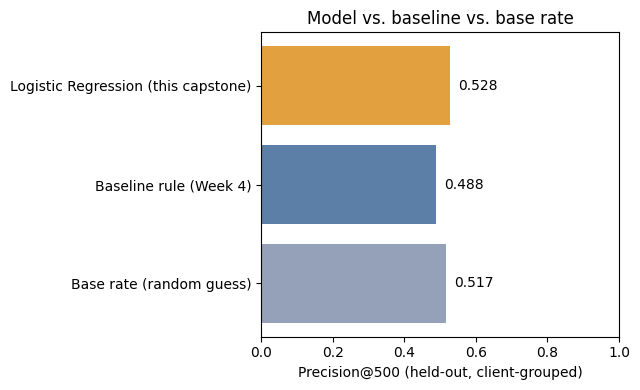

In [11]:
import matplotlib.pyplot as plt

colors = ["#94a1b8", "#5b7fa6", "#e2a03f"]

plt.figure(figsize=(6.5, 4))

plt.gca().set_facecolor("#131c30")
plt.gcf().patch.set_facecolor("#131c30")

bars = plt.barh(
    results["method"],
    results["precision_at_500"],
    color=colors
)

plt.xlabel(
    "Precision@500 (held-out, client-grouped)",
    color="#f5f7fb"
)

plt.title(
    "Model vs. baseline vs. base rate",
    color="#f5f7fb",
    fontsize=13,
    fontweight="bold"
)
plt.xlim(0, 1)
plt.xticks(color="#f5f7fb")
plt.yticks(color="#f5f7fb")

plt.bar_label(
    bars,
    fmt="%.3f",
    padding=6,
    color="#f5f7fb",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 5. Limitations

*What this work cannot claim.*

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.